<a href="https://colab.research.google.com/github/mohgeb/GlycemicPlus/blob/main/01_data_audit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

PROJECT = Path("/content/drive/MyDrive/GlycemicSentinel")

for folder in [
    "metadata",
    "processed",
    "models",
    "results"
]:
    (PROJECT / folder).mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT)

Mounted at /content/drive
Project directory: /content/drive/MyDrive/GlycemicSentinel


In [ ]:
!git clone https://github.com/PSI-TAMU/PhysioCGM.git /content/PhysioCGM

Cloning into '/content/PhysioCGM'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (122/122), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 122 (delta 47), reused 84 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (122/122), 9.81 MiB | 25.10 MiB/s, done.
Resolving deltas: 100% (47/47), done.


In [ ]:
%cd /content/PhysioCGM
!ls


/content/PhysioCGM
hypoglycemia_prediction  notebooks   preprocess.py  requirements.txt
libs			 output.png  README.md


In [ ]:
!pip install -q requests pandas numpy scipy scikit-learn matplotlib

In [ ]:
import requests
import pandas as pd

ARTICLE_ID = 28136294

url = f"https://api.figshare.com/v2/articles/{ARTICLE_ID}"

response = requests.get(url, timeout=60)
response.raise_for_status()

metadata = response.json()

print("Title:")
print(metadata["title"])
print()

files = metadata.get("files", [])

# Fallback if files aren't directly included in metadata
if not files:
    file_response = requests.get(
        f"https://api.figshare.com/v2/articles/{ARTICLE_ID}/files",
        timeout=60
    )
    file_response.raise_for_status()
    files = file_response.json()

file_table = pd.DataFrame([
    {
        "file_id": f.get("id"),
        "name": f.get("name"),
        "size_GB": round(f.get("size", 0) / 1024**3, 3),
        "download_url": f.get("download_url")
    }
    for f in files
])

display(
    file_table.sort_values("size_GB")
)

Title:
PhysioCGM: a multimodal physiological dataset for non-invasive blood glucose estimation



,file_id,name,size_GB,download_url
7,51655595,c2s03_raw.zip,0.731,https://ndownloader.figshare.com/files/51655595
0,51652388,c1s01_raw.zip,0.754,https://ndownloader.figshare.com/files/51652388
2,51653708,c1s03_raw.zip,0.786,https://ndownloader.figshare.com/files/51653708
3,51655547,c1s04_raw.zip,0.822,https://ndownloader.figshare.com/files/51655547
1,51653204,c1s02_raw.zip,0.837,https://ndownloader.figshare.com/files/51653204
6,51655574,c2s02_raw.zip,0.873,https://ndownloader.figshare.com/files/51655574
5,51655571,c2s01_raw.zip,0.890,https://ndownloader.figshare.com/files/51655571
9,51655613,c2s05_raw.zip,0.941,https://ndownloader.figshare.com/files/51655613
4,51655562,c1s05_raw.zip,0.948,https://ndownloader.figshare.com/files/51655562
8,51655601,c2s04_raw.zip,0.954,https://ndownloader.figshare.com/files/51655601


In [ ]:
processed_candidates = file_table[
    file_table["name"]
    .str.contains(
        "process|pkl|processed|c1s01",
        case=False,
        regex=True,
        na=False
    )
]

display(processed_candidates)

,file_id,name,size_GB,download_url
0,51652388,c1s01_raw.zip,0.754,https://ndownloader.figshare.com/files/51652388
10,51655652,c1s01_processed.zip,1.206,https://ndownloader.figshare.com/files/51655652
11,51656123,c1s02_processed.zip,1.448,https://ndownloader.figshare.com/files/51656123
12,51656129,c1s03_processed.zip,1.480,https://ndownloader.figshare.com/files/51656129
13,51656141,c1s04_processed.zip,1.295,https://ndownloader.figshare.com/files/51656141
14,51656147,c1s05_processed.zip,1.655,https://ndownloader.figshare.com/files/51656147
15,51656177,c2s01_processed.zip,1.561,https://ndownloader.figshare.com/files/51656177
16,51656189,c2s02_processed.zip,1.325,https://ndownloader.figshare.com/files/51656189
17,51656204,c2s03_processed.zip,1.387,https://ndownloader.figshare.com/files/51656204
18,51656228,c2s04_processed.zip,1.729,https://ndownloader.figshare.com/files/51656228


In [ ]:
import requests
from pathlib import Path

download_url = "https://ndownloader.figshare.com/files/51655652"
destination = Path("/content/c1s01_processed.zip")

with requests.get(download_url, stream=True, timeout=120) as r:
    r.raise_for_status()

    total = int(r.headers.get("content-length", 0))
    downloaded = 0

    with open(destination, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 1024):
            if chunk:
                f.write(chunk)
                downloaded += len(chunk)

                if total:
                    pct = downloaded / total * 100
                    print(f"\rDownloaded: {pct:.1f}%", end="")

print("\nSaved to:", destination)

Downloaded: 100.0%
Saved to: /content/c1s01_processed.zip


In [ ]:
import zipfile

zip_path = "/content/c1s01_processed.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    names = z.namelist()

print("Number of files:", len(names))

for name in names[:50]:
    print(name)

Number of files: 2704
0.pkl
1.pkl
10.pkl
100.pkl
1000.pkl
1001.pkl
1002.pkl
1003.pkl
1004.pkl
1005.pkl
1006.pkl
1007.pkl
1008.pkl
1009.pkl
101.pkl
1010.pkl
1011.pkl
1012.pkl
1013.pkl
1014.pkl
1015.pkl
1016.pkl
1017.pkl
1018.pkl
1019.pkl
102.pkl
1020.pkl
1021.pkl
1022.pkl
1023.pkl
1024.pkl
1025.pkl
1026.pkl
1027.pkl
1028.pkl
1029.pkl
103.pkl
1030.pkl
1031.pkl
1032.pkl
1033.pkl
1034.pkl
1035.pkl
1036.pkl
1037.pkl
1038.pkl
1039.pkl
104.pkl
1040.pkl
1041.pkl


In [ ]:
import zipfile
import pickle

zip_path = "/content/c1s01_processed.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    sample_name = "0.pkl"

    with z.open(sample_name) as f:
        sample = pickle.load(f)

print("Loaded:", sample_name)
print("Type:", type(sample))

Loaded: 0.pkl
Type: <class 'dict'>


In [ ]:
if isinstance(sample, dict):
    print("Keys:")
    for key in sample.keys():
        print("-", key)
else:
    print(sample)

Keys:
- Index
- Timestamp
- glucose
- zephyr
- e4


In [ ]:
import numpy as np
import pandas as pd

for key, value in sample.items():
    print(f"\n{key}")
    print("  type:", type(value))

    if hasattr(value, "shape"):
        print("  shape:", value.shape)

    elif isinstance(value, (list, tuple)):
        print("  length:", len(value))

    elif isinstance(value, dict):
        print("  subkeys:", list(value.keys()))

    else:
        print("  value:", value)


Index
  type: <class 'numpy.float64'>
  shape: ()

Timestamp
  type: <class 'pandas._libs.tslibs.timestamps.Timestamp'>
  value: 2022-06-08 13:33:48

glucose
  type: <class 'numpy.float64'>
  shape: ()

zephyr
  type: <class 'dict'>
  subkeys: ['Accel', 'Breathing', 'ECG', 'Summary']

e4
  type: <class 'dict'>
  subkeys: ['ACC', 'HR', 'BVP', 'EDA', 'TEMP']


In [ ]:
e4 = sample["e4"]

for key, value in e4.items():
    print(f"\nE4 -> {key}")
    print("  type:", type(value))

    if isinstance(value, dict):
        print("  subkeys:", list(value.keys()))

    if hasattr(value, "shape"):
        print("  shape:", value.shape)

    if isinstance(value, (list, tuple)):
        print("  length:", len(value))

    try:
        print("  first few:")
        print(value[:5])
    except Exception:
        pass


E4 -> ACC
  type: <class 'dict'>
  subkeys: ['Time', 'x', 'y', 'z']
  first few:

E4 -> HR
  type: <class 'dict'>
  subkeys: ['Time', 'HR']
  first few:

E4 -> BVP
  type: <class 'dict'>
  subkeys: ['Time', 'BVP']
  first few:

E4 -> EDA
  type: <class 'dict'>
  subkeys: ['Time', 'EDA']
  first few:

E4 -> TEMP
  type: <class 'dict'>
  subkeys: ['Time', 'TEMP']
  first few:


In [ ]:
print("Glucose:", sample["glucose"])
print("Timestamp:", sample["Timestamp"])

Glucose: 132.0
Timestamp: 2022-06-08 13:33:48


In [ ]:
sample["e4"]["BVP"]

{'Time': array(['2022-06-08T13:32:45.453125000', '2022-06-08T13:32:45.468750000',
        '2022-06-08T13:32:45.484375000', ...,
        '2022-06-08T13:33:47.953125000', '2022-06-08T13:33:47.968750000',
        '2022-06-08T13:33:47.984375000'], dtype='datetime64[ns]'),
 'BVP': array([-16.08, -26.66, -32.66, ...,  20.53,  18.98,  15.95])}

In [ ]:
import zipfile
import pickle
import pandas as pd
import numpy as np

zip_path = "/content/c1s01_processed.zip"

records = []

with zipfile.ZipFile(zip_path, "r") as z:

    pkl_files = [
        name for name in z.namelist()
        if name.endswith(".pkl")
    ]

    # Sort numerically: 0.pkl, 1.pkl, 2.pkl ...
    pkl_files = sorted(
        pkl_files,
        key=lambda x: int(x.replace(".pkl", ""))
    )

    for i, name in enumerate(pkl_files):

        with z.open(name) as f:
            s = pickle.load(f)

        glucose = s.get("glucose", np.nan)
        timestamp = s.get("Timestamp")

        e4 = s.get("e4", {})
        bvp = e4.get("BVP")

        # Determine BVP length safely
        try:
            bvp_length = len(bvp)
        except:
            bvp_length = 0

        records.append({
            "file": name,
            "timestamp": timestamp,
            "glucose": glucose,
            "bvp_length": bvp_length,
            "has_bvp": bvp_length > 0
        })

        if (i + 1) % 250 == 0:
            print(f"Processed {i + 1}/{len(pkl_files)}")

df = pd.DataFrame(records)

print("\nFinished.")
display(df.head())

Processed 250/2704
Processed 500/2704
Processed 750/2704
Processed 1000/2704
Processed 1250/2704
Processed 1500/2704
Processed 1750/2704
Processed 2000/2704
Processed 2250/2704
Processed 2500/2704

Finished.


,file,timestamp,glucose,bvp_length,has_bvp
0,0.pkl,2022-06-08 13:33:48,132.0,2,True
1,1.pkl,2022-06-08 13:38:47,130.0,2,True
2,2.pkl,2022-06-08 13:43:48,128.0,2,True
3,3.pkl,2022-06-08 13:48:48,135.0,2,True
4,4.pkl,2022-06-08 13:53:47,138.0,2,True


In [ ]:
print("Total windows:", len(df))

print("\nTimestamp range:")
print(df["timestamp"].min(), "→", df["timestamp"].max())

print("\nMissing glucose:", df["glucose"].isna().sum())

print("\nWindows with PPG:", df["has_bvp"].sum())

print("\nWindows without PPG:", (~df["has_bvp"]).sum())

print("\nGlucose statistics:")
display(df["glucose"].describe())

Total windows: 2704

Timestamp range:
2022-06-08 13:33:48 → 2022-06-28 16:40:14

Missing glucose: 0

Windows with PPG: 2704

Windows without PPG: 0

Glucose statistics:


,glucose
count,2704.000000
mean,115.862796
std,36.801434
min,40.000000
25%,91.000000
50%,110.000000
75%,132.000000
max,267.000000


In [ ]:
def glucose_category(g):
    if pd.isna(g):
        return "missing"

    if g < 54:
        return "severe_hypo"

    elif g < 70:
        return "hypo"

    elif g <= 180:
        return "in_range"

    elif g <= 250:
        return "hyper"

    else:
        return "severe_hyper"


df["glucose_category"] = df["glucose"].apply(glucose_category)

counts = df["glucose_category"].value_counts().sort_index()

display(counts)

,count
glucose_category,
hyper,176
hypo,124
in_range,2356
severe_hyper,10
severe_hypo,38


In [ ]:
percentages = (
    df["glucose_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(percentages)

,proportion
glucose_category,
in_range,87.13
hyper,6.51
hypo,4.59
severe_hypo,1.41
severe_hyper,0.37


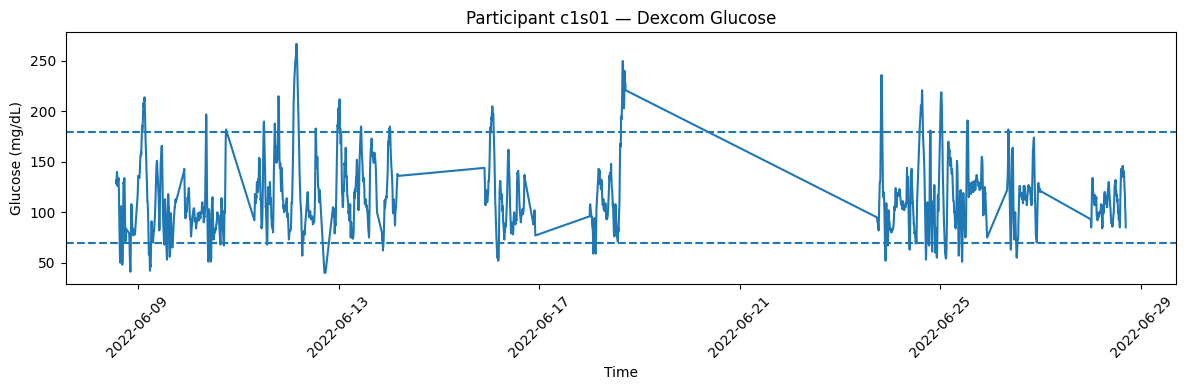

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(df["timestamp"], df["glucose"])
plt.axhline(70, linestyle="--")
plt.axhline(180, linestyle="--")

plt.xlabel("Time")
plt.ylabel("Glucose (mg/dL)")
plt.title("Participant c1s01 — Dexcom Glucose")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
df = df.sort_values("timestamp").reset_index(drop=True)

df["time_gap"] = df["timestamp"].diff()

print("Largest gaps:")
display(
    df[["timestamp", "time_gap"]]
    .sort_values("time_gap", ascending=False)
    .head(20)
)

print("\nGap statistics:")
display(df["time_gap"].describe())

Largest gaps:


,timestamp,time_gap
1714,2022-06-23 17:34:52,5 days 00:15:22
1269,2022-06-15 21:49:19,1 days 17:25:08
1514,2022-06-18 00:09:27,1 days 02:00:04
2503,2022-06-28 00:00:10,1 days 00:05:04
554,2022-06-11 07:43:59,0 days 13:35:02
2313,2022-06-26 07:55:02,0 days 09:35:01
311,2022-06-09 22:03:53,0 days 03:55:01
1501,2022-06-16 20:59:24,0 days 03:55:01
925,2022-06-12 21:19:05,0 days 03:35:00
1176,2022-06-13 20:44:09,0 days 02:20:00



Gap statistics:


,time_gap
count,2703
mean,0 days 00:10:43.428042915
std,0 days 02:33:35.375037395
min,0 days 00:00:09
25%,0 days 00:05:00
50%,0 days 00:05:00
75%,0 days 00:05:00
max,5 days 00:15:22


In [ ]:
for minutes in [6, 10, 30, 60, 180]:
    count = (df["time_gap"] > pd.Timedelta(minutes=minutes)).sum()
    print(f"Gaps > {minutes} minutes: {count}")

Gaps > 6 minutes: 22
Gaps > 10 minutes: 22
Gaps > 30 minutes: 18
Gaps > 60 minutes: 16
Gaps > 180 minutes: 9


In [ ]:
bvp = sample["e4"]["BVP"]

print("BVP object type:", type(bvp))
print("Keys:", bvp.keys())

for key, value in bvp.items():
    print(f"\n{key}")
    print("Type:", type(value))

    try:
        print("Length:", len(value))
    except TypeError:
        print("Length: scalar")

    if hasattr(value, "shape"):
        print("Shape:", value.shape)

    try:
        print("First 5 values:")
        print(value[:5])
    except Exception:
        pass

BVP object type: <class 'dict'>
Keys: dict_keys(['Time', 'BVP'])

Time
Type: <class 'numpy.ndarray'>
Length: 4003
Shape: (4003,)
First 5 values:
['2022-06-08T13:32:45.453125000' '2022-06-08T13:32:45.468750000'
 '2022-06-08T13:32:45.484375000' '2022-06-08T13:32:45.500000000'
 '2022-06-08T13:32:45.515625000']

BVP
Type: <class 'numpy.ndarray'>
Length: 4003
Shape: (4003,)
First 5 values:
[-16.08 -26.66 -32.66 -41.83 -60.92]


In [ ]:
import zipfile
import pickle
import pandas as pd
import numpy as np

zip_path = "/content/c1s01_processed.zip"

bvp_info = []

with zipfile.ZipFile(zip_path, "r") as z:

    pkl_files = sorted(
        [x for x in z.namelist() if x.endswith(".pkl")],
        key=lambda x: int(x.replace(".pkl", ""))
    )

    for i, name in enumerate(pkl_files):

        with z.open(name) as f:
            s = pickle.load(f)

        bvp_container = s.get("e4", {}).get("BVP", {})

        # Actual PPG waveform
        waveform = bvp_container.get("BVP")

        # Corresponding timestamps
        bvp_time = bvp_container.get("Time")

        if waveform is None:
            waveform_array = np.array([])
        else:
            waveform_array = np.asarray(waveform).reshape(-1)

        if bvp_time is None:
            time_array = np.array([])
        else:
            time_array = np.asarray(bvp_time).reshape(-1)

        bvp_info.append({
            "file": name,
            "timestamp": s.get("Timestamp"),
            "glucose": s.get("glucose"),

            "bvp_samples": len(waveform_array),
            "bvp_time_samples": len(time_array),

            "bvp_nan_count": (
                np.isnan(waveform_array).sum()
                if len(waveform_array) > 0
                and np.issubdtype(waveform_array.dtype, np.number)
                else np.nan
            ),

            "has_bvp": len(waveform_array) > 0
        })

        if (i + 1) % 250 == 0:
            print(f"Processed {i + 1}/{len(pkl_files)}")


bvp_df = pd.DataFrame(bvp_info)

print("\nDone.")
display(bvp_df.head())

Processed 250/2704
Processed 500/2704
Processed 750/2704
Processed 1000/2704
Processed 1250/2704
Processed 1500/2704
Processed 1750/2704
Processed 2000/2704
Processed 2250/2704
Processed 2500/2704

Done.


,file,timestamp,glucose,bvp_samples,bvp_time_samples,bvp_nan_count,has_bvp
0,0.pkl,2022-06-08 13:33:48,132.0,4003,4003,0.0,True
1,1.pkl,2022-06-08 13:38:47,130.0,8974,8974,0.0,True
2,2.pkl,2022-06-08 13:43:48,128.0,19263,19263,0.0,True
3,3.pkl,2022-06-08 13:48:48,135.0,19199,19199,0.0,True
4,4.pkl,2022-06-08 13:53:47,138.0,19135,19135,0.0,True


In [ ]:
print("Total windows:", len(bvp_df))

print("\nBVP sample-count distribution:")
display(
    bvp_df["bvp_samples"]
    .value_counts()
    .sort_index()
    .tail(20)
)

print("\nBVP sample statistics:")
display(bvp_df["bvp_samples"].describe())

print("\nWindows with no BVP:")
print((bvp_df["bvp_samples"] == 0).sum())

print("\nWindows where Time and BVP lengths differ:")
print(
    (
        bvp_df["bvp_samples"]
        != bvp_df["bvp_time_samples"]
    ).sum()
)

print("\nTotal PPG samples in this participant:")
print(f"{bvp_df['bvp_samples'].sum():,}")

Total windows: 2704

BVP sample-count distribution:


,count
bvp_samples,
16731,1
16803,1
17178,1
17360,1
17435,1
18396,1
18559,2
18623,1
18781,1



BVP sample statistics:


,bvp_samples
count,2704.000000
mean,18024.613536
std,4499.024163
min,0.000000
25%,19199.000000
50%,19199.000000
75%,19200.000000
max,19328.000000



Windows with no BVP:
141

Windows where Time and BVP lengths differ:
0

Total PPG samples in this participant:
48,738,555


In [ ]:
EXPECTED_BVP_SAMPLES = 64 * 60 * 5   # 19,200

bvp_df["coverage_ratio"] = (
    bvp_df["bvp_samples"] / EXPECTED_BVP_SAMPLES
)

print("Expected full-window samples:", EXPECTED_BVP_SAMPLES)

print("\nCoverage ratio statistics:")
display(bvp_df["coverage_ratio"].describe())

print(
    "\nWindows with >= 90% of expected PPG:",
    (bvp_df["coverage_ratio"] >= 0.90).sum()
)

print(
    "Windows with >= 95% of expected PPG:",
    (bvp_df["coverage_ratio"] >= 0.95).sum()
)

print(
    "Windows with full/near-full PPG:",
    (bvp_df["coverage_ratio"] >= 0.99).sum()
)

Expected full-window samples: 19200

Coverage ratio statistics:


,coverage_ratio
count,2704.000000
mean,0.938782
std,0.234324
min,0.000000
25%,0.999948
50%,0.999948
75%,1.000000
max,1.006667



Windows with >= 90% of expected PPG: 2521
Windows with >= 95% of expected PPG: 2519
Windows with full/near-full PPG: 2513


In [ ]:
# Merge glucose categories into the BVP audit table
bvp_df["glucose_category"] = bvp_df["glucose"].apply(glucose_category)

# Define usable PPG for now
bvp_df["usable_ppg"] = bvp_df["coverage_ratio"] >= 0.95

print("ALL WINDOWS")
print(
    bvp_df["glucose_category"]
    .value_counts()
)

print("\nUSABLE PPG WINDOWS ONLY")
usable_counts = (
    bvp_df.loc[bvp_df["usable_ppg"], "glucose_category"]
    .value_counts()
)

print(usable_counts)

print("\nUSABLE PPG WINDOWS BY PERCENT")
print(
    (
        bvp_df.loc[bvp_df["usable_ppg"], "glucose_category"]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

ALL WINDOWS
glucose_category
in_range        2356
hyper            176
hypo             124
severe_hypo       38
severe_hyper      10
Name: count, dtype: int64

USABLE PPG WINDOWS ONLY
glucose_category
in_range        2213
hyper            156
hypo             109
severe_hypo       31
severe_hyper      10
Name: count, dtype: int64

USABLE PPG WINDOWS BY PERCENT
glucose_category
in_range        87.85
hyper            6.19
hypo             4.33
severe_hypo      1.23
severe_hyper     0.40
Name: proportion, dtype: float64


In [ ]:
subject_summary = {
    "subject": "c1s01",
    "total_windows": len(bvp_df),
    "usable_ppg_windows": int(bvp_df["usable_ppg"].sum()),
    "usable_ppg_pct": round(bvp_df["usable_ppg"].mean() * 100, 2),

    "severe_hypo": int(
        (
            (bvp_df["glucose_category"] == "severe_hypo")
            & bvp_df["usable_ppg"]
        ).sum()
    ),

    "hypo": int(
        (
            (bvp_df["glucose_category"] == "hypo")
            & bvp_df["usable_ppg"]
        ).sum()
    ),

    "in_range": int(
        (
            (bvp_df["glucose_category"] == "in_range")
            & bvp_df["usable_ppg"]
        ).sum()
    ),

    "hyper": int(
        (
            (bvp_df["glucose_category"] == "hyper")
            & bvp_df["usable_ppg"]
        ).sum()
    ),

    "severe_hyper": int(
        (
            (bvp_df["glucose_category"] == "severe_hyper")
            & bvp_df["usable_ppg"]
        ).sum()
    )
}

pd.DataFrame([subject_summary])

,subject,total_windows,usable_ppg_windows,usable_ppg_pct,severe_hypo,hypo,in_range,hyper,severe_hyper
0,c1s01,2704,2519,93.16,31,109,2213,156,10


In [ ]:
import requests
import zipfile
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
import os


EXPECTED_BVP = 19200
MIN_COVERAGE = 0.95


def classify_glucose(g):
    if pd.isna(g):
        return "missing"
    elif g < 54:
        return "severe_hypo"
    elif g < 70:
        return "hypo"
    elif g <= 180:
        return "in_range"
    elif g <= 250:
        return "hyper"
    else:
        return "severe_hyper"


def audit_subject(zip_path, subject):

    rows = []

    with zipfile.ZipFile(zip_path, "r") as z:

        pkl_files = sorted(
            [x for x in z.namelist() if x.endswith(".pkl")],
            key=lambda x: int(Path(x).stem)
        )

        for i, filename in enumerate(pkl_files):

            with z.open(filename) as f:
                s = pickle.load(f)

            glucose = s.get("glucose", np.nan)
            timestamp = s.get("Timestamp")

            bvp_container = s.get("e4", {}).get("BVP", {})
            waveform = bvp_container.get("BVP")

            if waveform is None:
                n_samples = 0
            else:
                n_samples = len(np.asarray(waveform).reshape(-1))

            coverage = n_samples / EXPECTED_BVP

            rows.append({
                "subject": subject,
                "file": filename,
                "timestamp": timestamp,
                "glucose": glucose,
                "glucose_category": classify_glucose(glucose),
                "bvp_samples": n_samples,
                "coverage_ratio": coverage,
                "usable_ppg": coverage >= MIN_COVERAGE
            })

    return pd.DataFrame(rows)

In [ ]:
processed_files = file_table[
    file_table["name"].str.endswith("_processed.zip", na=False)
].copy()

processed_files["subject"] = (
    processed_files["name"]
    .str.replace("_processed.zip", "", regex=False)
)

display(
    processed_files[
        ["subject", "name", "size_GB", "download_url"]
    ]
)

,subject,name,size_GB,download_url
10,c1s01,c1s01_processed.zip,1.206,https://ndownloader.figshare.com/files/51655652
11,c1s02,c1s02_processed.zip,1.448,https://ndownloader.figshare.com/files/51656123
12,c1s03,c1s03_processed.zip,1.480,https://ndownloader.figshare.com/files/51656129
13,c1s04,c1s04_processed.zip,1.295,https://ndownloader.figshare.com/files/51656141
14,c1s05,c1s05_processed.zip,1.655,https://ndownloader.figshare.com/files/51656147
15,c2s01,c2s01_processed.zip,1.561,https://ndownloader.figshare.com/files/51656177
16,c2s02,c2s02_processed.zip,1.325,https://ndownloader.figshare.com/files/51656189
17,c2s03,c2s03_processed.zip,1.387,https://ndownloader.figshare.com/files/51656204
18,c2s04,c2s04_processed.zip,1.729,https://ndownloader.figshare.com/files/51656228
19,c2s05,c2s05_processed.zip,1.695,https://ndownloader.figshare.com/files/51656246


In [ ]:
from pathlib import Path
import requests
import os
import pandas as pd

TEMP_DIR = Path("/content/physiocgm_temp")
TEMP_DIR.mkdir(exist_ok=True)

AUDIT_DIR = PROJECT / "metadata"
AUDIT_DIR.mkdir(parents=True, exist_ok=True)

all_summaries = []

for _, row in processed_files.iterrows():

    subject = row["subject"]
    url = row["download_url"]

    zip_path = TEMP_DIR / f"{subject}_processed.zip"

    print("\n" + "=" * 60)
    print("SUBJECT:", subject)
    print("=" * 60)

    # If c1s01 already exists, reuse your existing copy
    existing_c1s01 = Path("/content/c1s01_processed.zip")

    if subject == "c1s01" and existing_c1s01.exists():
        zip_path = existing_c1s01
        downloaded_here = False

    else:
        downloaded_here = True
        print("Downloading...")

        with requests.get(url, stream=True, timeout=180) as r:
            r.raise_for_status()

            with open(zip_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=4 * 1024 * 1024):
                    if chunk:
                        f.write(chunk)

    print("Auditing...")
    audit = audit_subject(zip_path, subject)

    # Save per-window metadata permanently
    audit_path = AUDIT_DIR / f"{subject}_audit.csv"
    audit.to_csv(audit_path, index=False)

    usable = audit[audit["usable_ppg"]]

    summary = {
        "subject": subject,
        "total_windows": len(audit),
        "usable_windows": len(usable),
        "usable_pct": round(len(usable) / len(audit) * 100, 2),
        "severe_hypo": (usable["glucose_category"] == "severe_hypo").sum(),
        "hypo": (usable["glucose_category"] == "hypo").sum(),
        "in_range": (usable["glucose_category"] == "in_range").sum(),
        "hyper": (usable["glucose_category"] == "hyper").sum(),
        "severe_hyper": (usable["glucose_category"] == "severe_hyper").sum()
    }

    all_summaries.append(summary)

    print(pd.DataFrame([summary]).to_string(index=False))

    # Delete large temporary archive
    if downloaded_here and zip_path.exists():
        os.remove(zip_path)
        print("Temporary ZIP deleted.")


SUBJECT: c1s01
Auditing...
subject  total_windows  usable_windows  usable_pct  severe_hypo  hypo  in_range  hyper  severe_hyper
  c1s01           2704            2519       93.16           31   109      2213    156            10

SUBJECT: c1s02
Downloading...
Auditing...
subject  total_windows  usable_windows  usable_pct  severe_hypo  hypo  in_range  hyper  severe_hyper
  c1s02           3287            3121       94.95            0     8      2255    701           157
Temporary ZIP deleted.

SUBJECT: c1s03
Downloading...
Auditing...
subject  total_windows  usable_windows  usable_pct  severe_hypo  hypo  in_range  hyper  severe_hyper
  c1s03           3385            3085       91.14           16    89      2312    499           169
Temporary ZIP deleted.

SUBJECT: c1s04
Downloading...
Auditing...
subject  total_windows  usable_windows  usable_pct  severe_hypo  hypo  in_range  hyper  severe_hyper
  c1s04           2928            2491       85.08            0     6      1834    551    

In [ ]:
summary_df = pd.DataFrame(all_summaries)

display(summary_df)

summary_path = AUDIT_DIR / "physiocgm_subject_summary.csv"
summary_df.to_csv(summary_path, index=False)

print("Saved to:")
print(summary_path)

,subject,total_windows,usable_windows,usable_pct,severe_hypo,hypo,in_range,hyper,severe_hyper
0,c1s01,2704,2519,93.16,31,109,2213,156,10
1,c1s02,3287,3121,94.95,0,8,2255,701,157
2,c1s03,3385,3085,91.14,16,89,2312,499,169
3,c1s04,2928,2491,85.08,0,6,1834,551,100
4,c1s05,3765,3283,87.20,5,119,3132,27,0
5,c2s01,3498,3430,98.06,48,90,2851,396,45
6,c2s02,3069,2518,82.05,53,79,2281,105,0
7,c2s03,3288,2647,80.50,18,39,2263,314,13
8,c2s04,3798,3750,98.74,56,70,3129,433,62
9,c2s05,3712,3630,97.79,22,233,3237,116,22


Saved to:
/content/drive/MyDrive/GlycemicSentinel/metadata/physiocgm_subject_summary.csv


In [ ]:
numeric_cols = [
    "total_windows",
    "usable_windows",
    "severe_hypo",
    "hypo",
    "in_range",
    "hyper",
    "severe_hyper"
]

print("\nDATASET TOTALS")
display(
    summary_df[numeric_cols]
    .sum()
    .to_frame("count")
)


DATASET TOTALS


,count
total_windows,33434
usable_windows,30474
severe_hypo,249
hypo,842
in_range,25507
hyper,3298
severe_hyper,578


In [ ]:
for sensor_name, sensor_data in sample["e4"].items():

    print("\n", "=" * 50)
    print(sensor_name)
    print("=" * 50)

    print("Type:", type(sensor_data))

    if isinstance(sensor_data, dict):

        print("Keys:", sensor_data.keys())

        for key, value in sensor_data.items():

            print(f"\n  {key}")
            print("    Type:", type(value))

            try:
                print("    Length:", len(value))
            except:
                pass

            try:
                print("    First 3:", value[:3])
            except:
                pass


ACC
Type: <class 'dict'>
Keys: dict_keys(['Time', 'x', 'y', 'z'])

  Time
    Type: <class 'numpy.ndarray'>
    Length: 2001
    First 3: ['2022-06-08T13:32:45.468750000' '2022-06-08T13:32:45.500000000'
 '2022-06-08T13:32:45.531250000']

  x
    Type: <class 'numpy.ndarray'>
    Length: 2001
    First 3: [42. 45. 39.]

  y
    Type: <class 'numpy.ndarray'>
    Length: 2001
    First 3: [-24. -23. -21.]

  z
    Type: <class 'numpy.ndarray'>
    Length: 2001
    First 3: [  1.  -1. -12.]

HR
Type: <class 'dict'>
Keys: dict_keys(['Time', 'HR'])

  Time
    Type: <class 'numpy.ndarray'>
    Length: 62
    First 3: ['2022-06-08T13:32:46.000000000' '2022-06-08T13:32:47.000000000'
 '2022-06-08T13:32:48.000000000']

  HR
    Type: <class 'numpy.ndarray'>
    Length: 62
    First 3: [83.08 83.37 83.63]

BVP
Type: <class 'dict'>
Keys: dict_keys(['Time', 'BVP'])

  Time
    Type: <class 'numpy.ndarray'>
    Length: 4003
    First 3: ['2022-06-08T13:32:45.453125000' '2022-06-08T13:32:45.46875000

In [ ]:
import zipfile
import pickle
import pandas as pd

zip_path = "/content/c1s01_processed.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("3.pkl") as f:
        s = pickle.load(f)

cgm_time = pd.Timestamp(s["Timestamp"])

print("CGM timestamp:", cgm_time)
print("Glucose:", s["glucose"])

for sensor in ["BVP", "ACC", "HR", "EDA", "TEMP"]:

    data = s["e4"][sensor]
    times = pd.to_datetime(data["Time"])

    start = times.min()
    end = times.max()

    print(f"\n{sensor}")
    print("  Samples:", len(times))
    print("  Start:", start)
    print("  End:", end)
    print("  Duration:", end - start)
    print("  Start relative to CGM:", start - cgm_time)
    print("  End relative to CGM:", end - cgm_time)

CGM timestamp: 2022-06-08 13:48:48
Glucose: 135.0

BVP
  Samples: 19199
  Start: 2022-06-08 13:43:48.015625
  End: 2022-06-08 13:48:47.984375
  Duration: 0 days 00:04:59.968750
  Start relative to CGM: -1 days +23:55:00.015625
  End relative to CGM: -1 days +23:59:59.984375

ACC
  Samples: 9599
  Start: 2022-06-08 13:43:48.031250
  End: 2022-06-08 13:48:47.968750
  Duration: 0 days 00:04:59.937500
  Start relative to CGM: -1 days +23:55:00.031250
  End relative to CGM: -1 days +23:59:59.968750

HR
  Samples: 299
  Start: 2022-06-08 13:43:49
  End: 2022-06-08 13:48:47
  Duration: 0 days 00:04:58
  Start relative to CGM: -1 days +23:55:01
  End relative to CGM: -1 days +23:59:59

EDA
  Samples: 1199
  Start: 2022-06-08 13:43:48.250000
  End: 2022-06-08 13:48:47.750000
  Duration: 0 days 00:04:59.500000
  Start relative to CGM: -1 days +23:55:00.250000
  End relative to CGM: -1 days +23:59:59.750000

TEMP
  Samples: 1199
  Start: 2022-06-08 13:43:48.250000
  End: 2022-06-08 13:48:47.75000

In [ ]:
import numpy as np
import pandas as pd


PPG_FS = 64
WINDOW_SECONDS = 300
PPG_LENGTH = PPG_FS * WINDOW_SECONDS   # 19,200


def extract_fixed_ppg(sample):
    """
    Convert one PhysioCGM BVP window into an exact
    5-minute, 64-Hz PPG array ending at the CGM timestamp.

    Returns:
        np.ndarray shape (19200,) or None
    """

    cgm_time = pd.Timestamp(sample["Timestamp"])

    bvp_data = sample.get("e4", {}).get("BVP", {})

    if "Time" not in bvp_data or "BVP" not in bvp_data:
        return None

    times = pd.to_datetime(bvp_data["Time"])
    values = np.asarray(
        bvp_data["BVP"],
        dtype=np.float32
    ).reshape(-1)

    if len(times) != len(values) or len(values) == 0:
        return None

    # Convert timestamps to seconds relative to the CGM target.
    relative_seconds = (
        times - cgm_time
    ).total_seconds().to_numpy()

    # Remove invalid samples
    mask = (
        np.isfinite(relative_seconds)
        & np.isfinite(values)
    )

    relative_seconds = relative_seconds[mask]
    values = values[mask]

    if len(values) == 0:
        return None

    # Keep only data from the preceding five minutes.
    mask = (
        (relative_seconds >= -WINDOW_SECONDS)
        & (relative_seconds < 0)
    )

    relative_seconds = relative_seconds[mask]
    values = values[mask]

    if len(values) < int(PPG_LENGTH * 0.99):
        return None

    # Require coverage close to BOTH edges of the window.
    # Prevents us from stretching a partial segment across 5 min.
    if relative_seconds.min() > -299:
        return None

    if relative_seconds.max() < -1:
        return None

    # Sort chronologically
    order = np.argsort(relative_seconds)

    relative_seconds = relative_seconds[order]
    values = values[order]

    # Exact 64-Hz time grid:
    # -300 sec ... immediately before CGM measurement
    target_grid = np.arange(
        -WINDOW_SECONDS,
        0,
        1 / PPG_FS
    )

    # Make absolutely sure length is exactly 19,200
    target_grid = target_grid[:PPG_LENGTH]

    fixed_ppg = np.interp(
        target_grid,
        relative_seconds,
        values
    ).astype(np.float32)

    return fixed_ppg

In [ ]:
import zipfile
import pickle

zip_path = "/content/c1s01_processed.zip"

with zipfile.ZipFile(zip_path, "r") as z:

    with z.open("3.pkl") as f:
        test_sample = pickle.load(f)

ppg = extract_fixed_ppg(test_sample)

print("PPG shape:", ppg.shape)
print("Samples:", len(ppg))
print("Glucose:", test_sample["glucose"])
print("Timestamp:", test_sample["Timestamp"])

print("\nPPG statistics:")
print("Minimum:", ppg.min())
print("Maximum:", ppg.max())
print("Mean:", ppg.mean())
print("Std:", ppg.std())

PPG shape: (19200,)
Samples: 19200
Glucose: 135.0
Timestamp: 2022-06-08 13:48:48

PPG statistics:
Minimum: -826.29
Maximum: 634.41
Mean: -0.08629016
Std: 121.926895


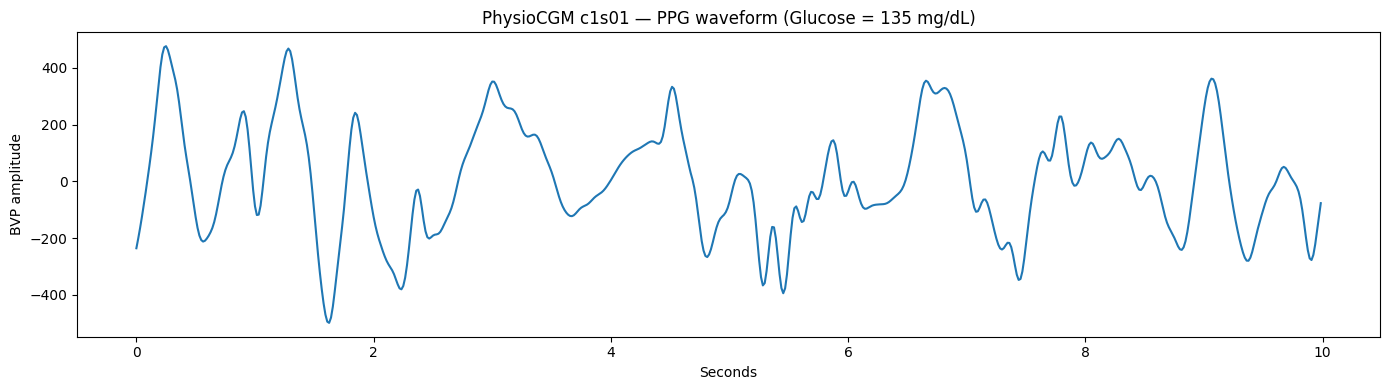

In [ ]:
import matplotlib.pyplot as plt

seconds_to_show = 10
samples_to_show = PPG_FS * seconds_to_show

time_axis = np.arange(samples_to_show) / PPG_FS

plt.figure(figsize=(14, 4))

plt.plot(
    time_axis,
    ppg[-samples_to_show:]
)

plt.xlabel("Seconds")
plt.ylabel("BVP amplitude")
plt.title(
    f"PhysioCGM c1s01 — PPG waveform "
    f"(Glucose = {test_sample['glucose']:.0f} mg/dL)"
)

plt.tight_layout()
plt.show()

In [ ]:
def glucose_label(glucose):
    """
    0 = hypoglycemia
    1 = in range
    2 = hyperglycemia
    """

    if glucose < 70:
        return 0

    elif glucose <= 180:
        return 1

    else:
        return 2

In [ ]:
for glucose in [45, 65, 100, 180, 181, 300]:
    print(glucose, "→", glucose_label(glucose))

45 → 0
65 → 0
100 → 1
180 → 1
181 → 2
300 → 2


In [ ]:
import numpy as np
import pandas as pd
import zipfile
import pickle
import matplotlib.pyplot as plt

PPG_FS = 64
WINDOW_SECONDS = 300
PPG_LENGTH = PPG_FS * WINDOW_SECONDS  # 19,200


def extract_fixed_ppg(sample):

    cgm_time = pd.Timestamp(sample["Timestamp"])

    bvp_data = sample.get("e4", {}).get("BVP", {})

    if "Time" not in bvp_data or "BVP" not in bvp_data:
        return None

    times = pd.to_datetime(bvp_data["Time"])

    values = np.asarray(
        bvp_data["BVP"],
        dtype=np.float32
    ).reshape(-1)

    if len(times) != len(values) or len(values) == 0:
        return None

    relative_seconds = (
        times - cgm_time
    ).total_seconds().to_numpy()

    valid = (
        np.isfinite(relative_seconds)
        & np.isfinite(values)
        & (relative_seconds >= -300)
        & (relative_seconds < 0)
    )

    relative_seconds = relative_seconds[valid]
    values = values[valid]

    # Require ~99% completeness
    if len(values) < int(PPG_LENGTH * 0.99):
        return None

    # Require coverage across nearly the whole 5-minute interval
    if relative_seconds.min() > -299:
        return None

    if relative_seconds.max() < -1:
        return None

    order = np.argsort(relative_seconds)

    relative_seconds = relative_seconds[order]
    values = values[order]

    target_grid = np.arange(
        -300,
        0,
        1 / PPG_FS
    )[:PPG_LENGTH]

    fixed_ppg = np.interp(
        target_grid,
        relative_seconds,
        values
    ).astype(np.float32)

    return fixed_ppg

In [ ]:
zip_path = "/content/c1s01_processed.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    with z.open("3.pkl") as f:
        sample = pickle.load(f)

ppg = extract_fixed_ppg(sample)

print("Shape:", ppg.shape)
print("Glucose:", sample["glucose"])
print("Timestamp:", sample["Timestamp"])
print("Mean:", ppg.mean())
print("Std:", ppg.std())

Shape: (19200,)
Glucose: 135.0
Timestamp: 2022-06-08 13:48:48
Mean: -0.08629016
Std: 121.926895


In [ ]:
def glucose_label(glucose):
    if glucose < 70:
        return 0       # hypo
    elif glucose <= 180:
        return 1       # in range
    else:
        return 2       # hyper

In [ ]:
!pip install -q h5py

In [ ]:
import h5py
import shutil
import os
from pathlib import Path

PROCESSED_DIR = PROJECT / "processed" / "ppg_v1"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

TEMP_DIR = Path("/content/physiocgm_build")
TEMP_DIR.mkdir(exist_ok=True)

In [ ]:
def build_subject_h5(zip_path, subject, output_path):

    accepted = 0
    rejected = 0

    with zipfile.ZipFile(zip_path, "r") as z:

        pkl_files = sorted(
            [x for x in z.namelist() if x.endswith(".pkl")],
            key=lambda x: int(Path(x).stem)
        )

        with h5py.File(output_path, "w") as h5:

            # Resizable datasets
            ppg_ds = h5.create_dataset(
                "ppg",
                shape=(0, PPG_LENGTH),
                maxshape=(None, PPG_LENGTH),
                dtype="float32",
                chunks=(1, PPG_LENGTH),
                compression="gzip",
                compression_opts=4
            )

            glucose_ds = h5.create_dataset(
                "glucose",
                shape=(0,),
                maxshape=(None,),
                dtype="float32"
            )

            label_ds = h5.create_dataset(
                "label",
                shape=(0,),
                maxshape=(None,),
                dtype="uint8"
            )

            timestamp_ds = h5.create_dataset(
                "timestamp_ns",
                shape=(0,),
                maxshape=(None,),
                dtype="int64"
            )

            for i, filename in enumerate(pkl_files):

                with z.open(filename) as f:
                    sample = pickle.load(f)

                ppg = extract_fixed_ppg(sample)

                if ppg is None:
                    rejected += 1
                    continue

                glucose = float(sample["glucose"])

                if not np.isfinite(glucose):
                    rejected += 1
                    continue

                label = glucose_label(glucose)

                timestamp_ns = pd.Timestamp(
                    sample["Timestamp"]
                ).value

                idx = accepted

                ppg_ds.resize(idx + 1, axis=0)
                glucose_ds.resize(idx + 1, axis=0)
                label_ds.resize(idx + 1, axis=0)
                timestamp_ds.resize(idx + 1, axis=0)

                ppg_ds[idx] = ppg
                glucose_ds[idx] = glucose
                label_ds[idx] = label
                timestamp_ds[idx] = timestamp_ns

                accepted += 1

                if (i + 1) % 250 == 0:
                    print(
                        f"{subject}: "
                        f"{i+1}/{len(pkl_files)} scanned, "
                        f"{accepted} accepted"
                    )

            h5.attrs["subject"] = subject
            h5.attrs["ppg_sampling_rate"] = 64
            h5.attrs["window_seconds"] = 300
            h5.attrs["ppg_length"] = 19200

    return accepted, rejected

In [53]:
local_output = TEMP_DIR / "c1s01.h5"

accepted, rejected = build_subject_h5(
    "/content/c1s01_processed.zip",
    "c1s01",
    local_output
)

print("Accepted:", accepted)
print("Rejected:", rejected)
print("File size MB:", local_output.stat().st_size / 1024**2)

c1s01: 250/2704 scanned, 205 accepted
c1s01: 500/2704 scanned, 409 accepted
c1s01: 750/2704 scanned, 611 accepted
c1s01: 1000/2704 scanned, 805 accepted
c1s01: 1500/2704 scanned, 1139 accepted
c1s01: 1750/2704 scanned, 1348 accepted
c1s01: 2000/2704 scanned, 1556 accepted
c1s01: 2250/2704 scanned, 1741 accepted
c1s01: 2500/2704 scanned, 1951 accepted
Accepted: 2124
Rejected: 580
File size MB: 107.99863624572754


In [54]:
with h5py.File(local_output, "r") as h5:

    print("Datasets:", list(h5.keys()))

    print("PPG:", h5["ppg"].shape)
    print("Glucose:", h5["glucose"].shape)
    print("Labels:", h5["label"].shape)

    labels, counts = np.unique(
        h5["label"][:],
        return_counts=True
    )

    print("\nClass counts:")
    for label, count in zip(labels, counts):
        print(label, count)

Datasets: ['glucose', 'label', 'ppg', 'timestamp_ns']
PPG: (2124, 19200)
Glucose: (2124,)
Labels: (2124,)

Class counts:
0 115
1 1875
2 134


In [55]:
import h5py
import numpy as np

with h5py.File(local_output, "r") as h5:

    glucose = h5["glucose"][:]
    labels = h5["label"][:]

    print("PPG dtype:", h5["ppg"].dtype)
    print("PPG shape:", h5["ppg"].shape)

    print("\n--- LABEL CHECK ---")

    for label, name in [
        (0, "HYPO"),
        (1, "IN RANGE"),
        (2, "HYPER")
    ]:
        g = glucose[labels == label]

        print(
            f"{name:10s} | "
            f"n={len(g):4d} | "
            f"min={g.min():6.1f} | "
            f"mean={g.mean():6.1f} | "
            f"max={g.max():6.1f}"
        )

    # Verify labels really correspond to the thresholds
    assert np.all(glucose[labels == 0] < 70)

    assert np.all(
        (glucose[labels == 1] >= 70) &
        (glucose[labels == 1] <= 180)
    )

    assert np.all(glucose[labels == 2] > 180)

    print("\n✓ Glucose labels are internally consistent.")

PPG dtype: float32
PPG shape: (2124, 19200)

--- LABEL CHECK ---
HYPO       | n= 115 | min=  41.0 | mean=  59.4 | max=  69.0
IN RANGE   | n=1875 | min=  70.0 | mean= 112.4 | max= 180.0
HYPER      | n= 134 | min= 181.0 | mean= 206.1 | max= 266.0

✓ Glucose labels are internally consistent.


In [56]:
with h5py.File(local_output, "r") as h5:

    ppg = h5["ppg"]

    bad_windows = 0
    flat_windows = 0

    batch_size = 128

    for start in range(0, len(ppg), batch_size):

        x = ppg[start:start + batch_size]

        bad_windows += np.sum(
            ~np.isfinite(x).all(axis=1)
        )

        flat_windows += np.sum(
            np.std(x, axis=1) < 1e-6
        )

    print("Non-finite PPG windows:", bad_windows)
    print("Flat PPG windows:", flat_windows)

Non-finite PPG windows: 0
Flat PPG windows: 0


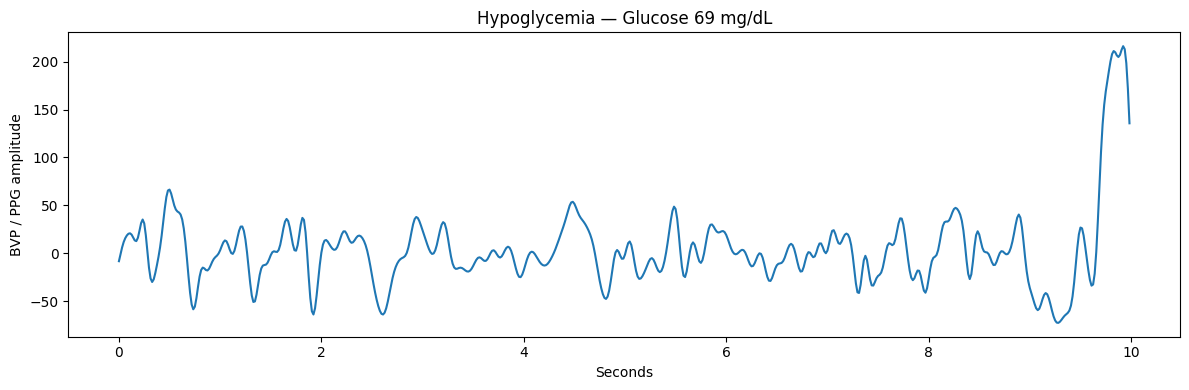

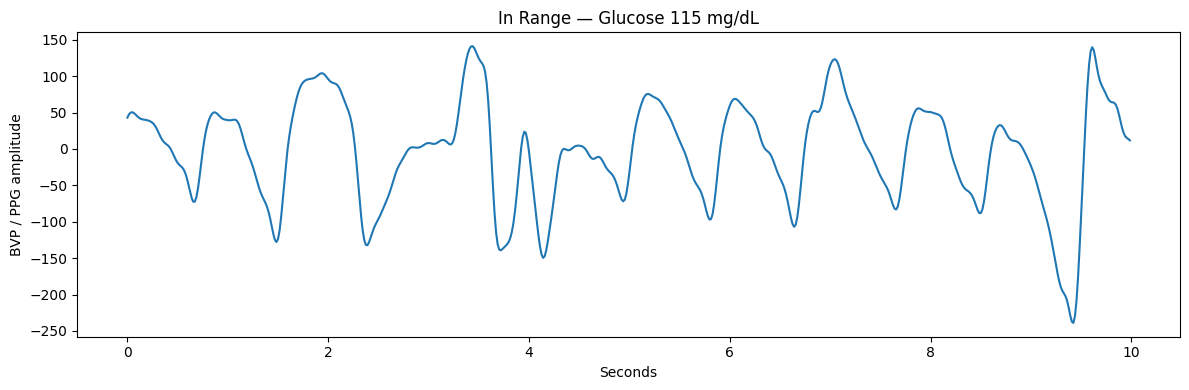

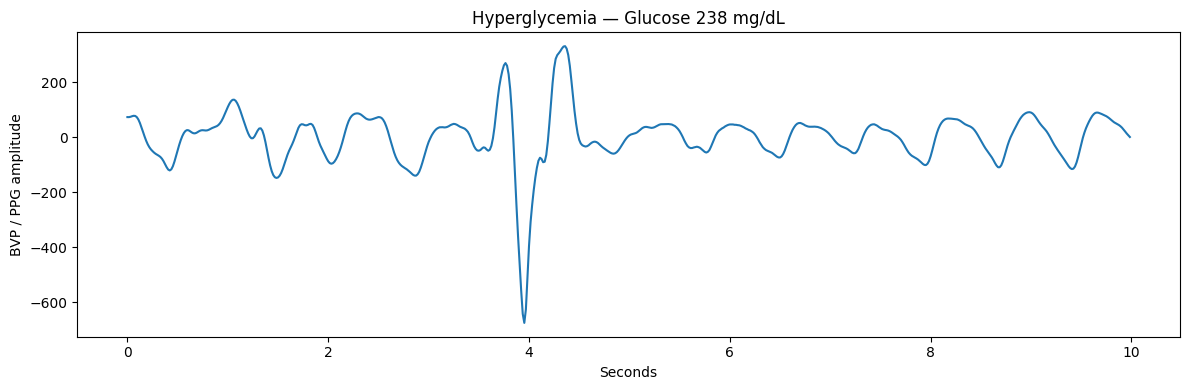

In [57]:
import matplotlib.pyplot as plt

with h5py.File(local_output, "r") as h5:

    ppg = h5["ppg"]
    labels = h5["label"][:]
    glucose = h5["glucose"][:]

    rng = np.random.default_rng(42)

    names = {
        0: "Hypoglycemia",
        1: "In Range",
        2: "Hyperglycemia"
    }

    # Show 10 seconds = 640 samples
    segment_length = 64 * 10

    for label in [0, 1, 2]:

        candidates = np.where(labels == label)[0]
        idx = rng.choice(candidates)

        signal = ppg[idx]

        # Take 10 seconds from the center of the 5-minute window
        center = len(signal) // 2
        segment = signal[
            center - segment_length // 2 :
            center + segment_length // 2
        ]

        time = np.arange(len(segment)) / 64

        plt.figure(figsize=(12, 4))
        plt.plot(time, segment)

        plt.title(
            f"{names[label]} — "
            f"Glucose {glucose[idx]:.0f} mg/dL"
        )

        plt.xlabel("Seconds")
        plt.ylabel("BVP / PPG amplitude")
        plt.tight_layout()
        plt.show()

In [58]:
import numpy as np
import h5py
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt


FS = 64

def clean_ppg(x, fs=FS):
    x = np.asarray(x, dtype=np.float64)

    # Band-pass filter
    sos = butter(
        N=4,
        Wn=[0.5, 8.0],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    filtered = sosfiltfilt(sos, x)

    # Robust normalization
    median = np.median(filtered)
    mad = np.median(np.abs(filtered - median))

    if mad < 1e-8:
        return filtered - median

    normalized = (filtered - median) / (1.4826 * mad)

    return normalized

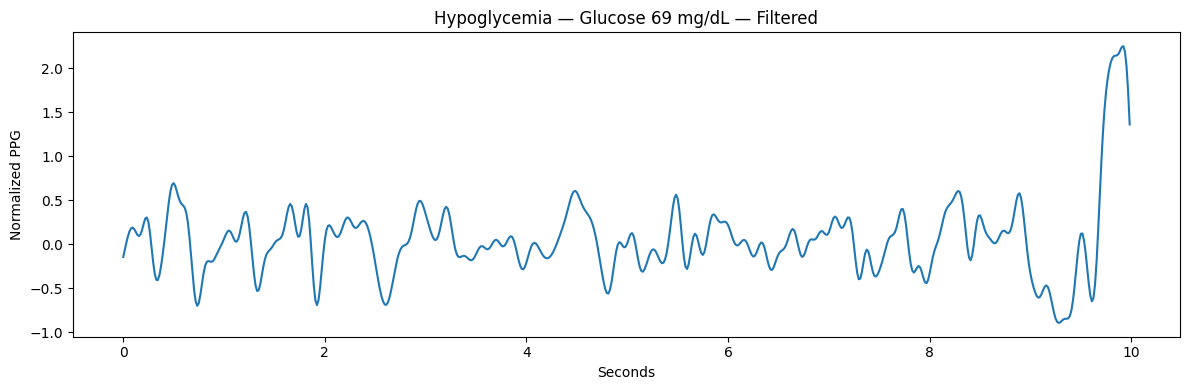

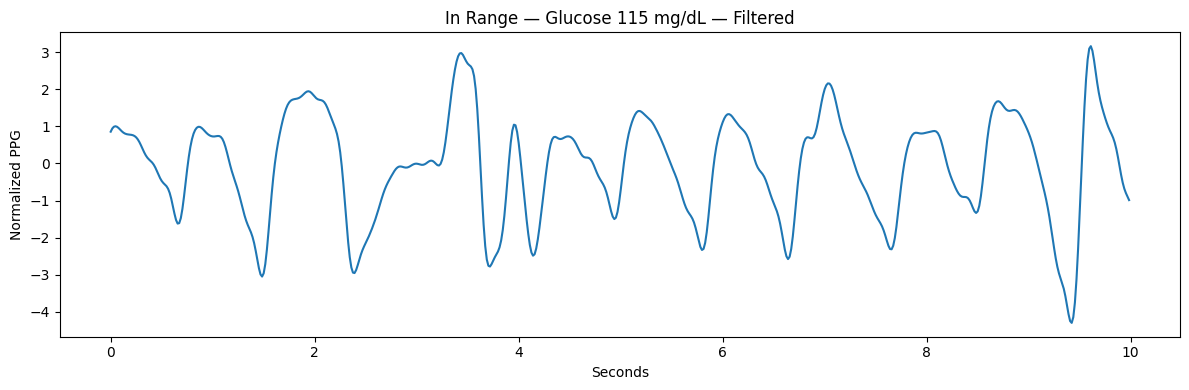

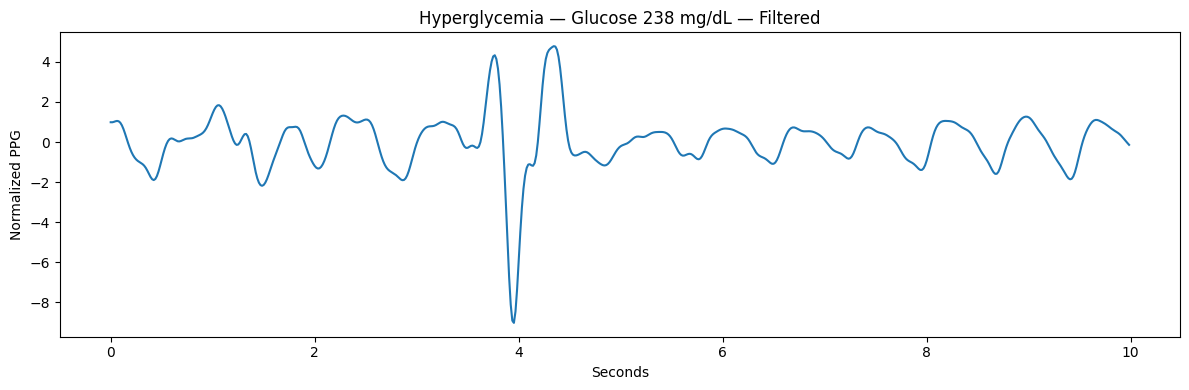

In [59]:
with h5py.File(local_output, "r") as h5:

    ppg = h5["ppg"]
    labels = h5["label"][:]
    glucose = h5["glucose"][:]

    names = {
        0: "Hypoglycemia",
        1: "In Range",
        2: "Hyperglycemia"
    }

    rng = np.random.default_rng(42)

    segment_length = FS * 10

    for label in [0, 1, 2]:

        candidates = np.where(labels == label)[0]
        idx = rng.choice(candidates)

        raw = ppg[idx]
        cleaned = clean_ppg(raw)

        center = len(cleaned) // 2

        segment = cleaned[
            center - segment_length // 2:
            center + segment_length // 2
        ]

        time = np.arange(len(segment)) / FS

        plt.figure(figsize=(12, 4))
        plt.plot(time, segment)

        plt.title(
            f"{names[label]} — "
            f"Glucose {glucose[idx]:.0f} mg/dL — Filtered"
        )

        plt.xlabel("Seconds")
        plt.ylabel("Normalized PPG")
        plt.tight_layout()
        plt.show()

In [61]:
from pathlib import Path
import requests
import shutil
import os
import pandas as pd

# 1. Where permanent H5 files will be saved
OUTPUT_DIR = Path(
    "/content/drive/MyDrive/GlycemicSentinel/processed"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TEMP_DOWNLOADS = Path("/content/physiocgm_downloads")
TEMP_DOWNLOADS.mkdir(parents=True, exist_ok=True)


# 2. PhysioCGM processed participant files
subjects = {
    "c1s01": "https://ndownloader.figshare.com/files/51655652",
    "c1s02": "https://ndownloader.figshare.com/files/51656123",
    "c1s03": "https://ndownloader.figshare.com/files/51656129",
    "c1s04": "https://ndownloader.figshare.com/files/51656141",
    "c1s05": "https://ndownloader.figshare.com/files/51656147",

    "c2s01": "https://ndownloader.figshare.com/files/51656177",
    "c2s02": "https://ndownloader.figshare.com/files/51656189",
    "c2s03": "https://ndownloader.figshare.com/files/51656204",
    "c2s04": "https://ndownloader.figshare.com/files/51656228",
    "c2s05": "https://ndownloader.figshare.com/files/51656246",
}


# 3. Helper: download one participant
def download_file(url, destination):

    print(f"Downloading → {destination.name}")

    with requests.get(url, stream=True, timeout=300) as r:
        r.raise_for_status()

        total = int(r.headers.get("content-length", 0))
        downloaded = 0

        with open(destination, "wb") as f:

            for chunk in r.iter_content(
                chunk_size=4 * 1024 * 1024
            ):

                if not chunk:
                    continue

                f.write(chunk)
                downloaded += len(chunk)

                if total:
                    pct = downloaded / total * 100
                    print(
                        f"\rDownload: {pct:5.1f}%",
                        end=""
                    )

    print("\nDownload finished.")


# 4. Process every participant
summary_rows = []

for subject, url in subjects.items():

    print("\n")
    print("=" * 60)
    print(f"PROCESSING {subject}")
    print("=" * 60)

    final_h5 = OUTPUT_DIR / f"{subject}.h5"

    if final_h5.exists():

        print(f"{subject}.h5 already exists — skipping.")

        # Read existing file to recover counts
        with h5py.File(final_h5, "r") as h5:

            labels = h5["label"][:]

            summary_rows.append({
                "subject": subject,
                "accepted": len(labels),
                "hypo": int((labels == 0).sum()),
                "in_range": int((labels == 1).sum()),
                "hyper": int((labels == 2).sum()),
                "file_MB":
                    round(final_h5.stat().st_size / 1024**2, 1)
            })

        continue


    # Reuse c1s01 ZIP if it is still in Colab
    existing_c1s01 = Path(
        "/content/c1s01_processed.zip"
    )

    if (
        subject == "c1s01"
        and existing_c1s01.exists()
    ):

        zip_path = existing_c1s01
        delete_after = False

        print("Using existing c1s01 ZIP.")

    else:

        zip_path = (
            TEMP_DOWNLOADS /
            f"{subject}_processed.zip"
        )

        delete_after = True

        if not zip_path.exists():
            download_file(url, zip_path)


    # Build HDF5 using YOUR working function
    temp_h5 = (
        TEMP_DOWNLOADS /
        f"{subject}.h5"
    )

    print("\nBuilding training file...")

    accepted, rejected = build_subject_h5(
        zip_path,
        subject,
        temp_h5
    )

    print("\nAccepted:", accepted)
    print("Rejected:", rejected)



    # Move completed H5 permanently to Google Drive
    shutil.move(
        str(temp_h5),
        str(final_h5)
    )

    print("Saved permanently:")
    print(final_h5)



    # Inspect class counts
    with h5py.File(final_h5, "r") as h5:

        labels = h5["label"][:]

        hypo = int((labels == 0).sum())
        normal = int((labels == 1).sum())
        hyper = int((labels == 2).sum())

    print("\nClasses:")
    print("Hypoglycemia:", hypo)
    print("In range:", normal)
    print("Hyperglycemia:", hyper)


    summary_rows.append({
        "subject": subject,
        "accepted": accepted,
        "rejected": rejected,
        "hypo": hypo,
        "in_range": normal,
        "hyper": hyper,
        "file_MB":
            round(final_h5.stat().st_size / 1024**2, 1)
    })


    # Delete the huge ZIP after successful processing
    if delete_after and zip_path.exists():

        os.remove(zip_path)

        print(
            "\nTemporary ZIP deleted "
            "to free Colab storage."
        )

    # Save progress after EACH participant
    summary_df = pd.DataFrame(summary_rows)

    summary_df.to_csv(
        OUTPUT_DIR / "training_dataset_summary.csv",
        index=False
    )

    print("\nProgress saved.")


print("\n")
print("=" * 60)
print("ALL AVAILABLE SUBJECTS FINISHED")
print("=" * 60)

summary_df = pd.DataFrame(summary_rows)

display(summary_df)



PROCESSING c1s01
Using existing c1s01 ZIP.

Building training file...
c1s01: 250/2704 scanned, 205 accepted
c1s01: 500/2704 scanned, 409 accepted
c1s01: 750/2704 scanned, 611 accepted
c1s01: 1000/2704 scanned, 805 accepted
c1s01: 1500/2704 scanned, 1139 accepted
c1s01: 1750/2704 scanned, 1348 accepted
c1s01: 2000/2704 scanned, 1556 accepted
c1s01: 2250/2704 scanned, 1741 accepted
c1s01: 2500/2704 scanned, 1951 accepted

Accepted: 2124
Rejected: 580
Saved permanently:
/content/drive/MyDrive/GlycemicSentinel/processed/c1s01.h5

Classes:
Hypoglycemia: 115
In range: 1875
Hyperglycemia: 134

Progress saved.


PROCESSING c1s02
Download: 100.0%
Download finished.

Building training file...
c1s02: 250/3287 scanned, 206 accepted
c1s02: 750/3287 scanned, 607 accepted
c1s02: 1000/3287 scanned, 802 accepted
c1s02: 1250/3287 scanned, 1006 accepted
c1s02: 1500/3287 scanned, 1192 accepted
c1s02: 1750/3287 scanned, 1380 accepted
c1s02: 2000/3287 scanned, 1584 accepted
c1s02: 2750/3287 scanned, 2156 

,subject,accepted,rejected,hypo,in_range,hyper,file_MB
0,c1s01,2124,580,115,1875,134,108.0
1,c1s02,2592,695,7,1881,704,128.8
2,c1s03,2550,835,86,1893,571,122.4
3,c1s04,2145,783,3,1583,559,111.9
4,c1s05,2745,1020,108,2614,23,140.3
5,c2s01,2947,551,109,2453,385,152.3
6,c2s02,2098,971,117,1893,88,107.8
7,c2s03,2202,1086,43,1885,274,108.2
8,c2s04,3139,659,104,2619,416,164.1
9,c2s05,3058,654,202,2743,113,154.8


In [62]:
from pathlib import Path
import h5py

OUTPUT_DIR = Path(
    "/content/drive/MyDrive/GlycemicSentinel/processed"
)

h5_files = sorted(OUTPUT_DIR.glob("*.h5"))

print("H5 files found:", len(h5_files))

for file in h5_files:
    with h5py.File(file, "r") as h5:
        print(
            file.name,
            "PPG:", h5["ppg"].shape,
            "Labels:", h5["label"].shape
        )

H5 files found: 10
c1s01.h5 PPG: (2124, 19200) Labels: (2124,)
c1s02.h5 PPG: (2592, 19200) Labels: (2592,)
c1s03.h5 PPG: (2550, 19200) Labels: (2550,)
c1s04.h5 PPG: (2145, 19200) Labels: (2145,)
c1s05.h5 PPG: (2745, 19200) Labels: (2745,)
c2s01.h5 PPG: (2947, 19200) Labels: (2947,)
c2s02.h5 PPG: (2098, 19200) Labels: (2098,)
c2s03.h5 PPG: (2202, 19200) Labels: (2202,)
c2s04.h5 PPG: (3139, 19200) Labels: (3139,)
c2s05.h5 PPG: (3058, 19200) Labels: (3058,)
